Part 1: Import Libraries & Load Dataset

In [9]:
# ==========================================
# SUPPORT TICKET CLASSIFICATION
# Future Interns - Task 2
# Author: Shashikant Jha
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text Processing
import re
import string

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [10]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets (1).csv


In [11]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [12]:
print("Rows and Columns:", df.shape)

Rows and Columns: (8469, 17)


In [13]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
df.describe(include='all')

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,We seat culture plan.,Medium,Email,2023-06-01 20:45:39,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [17]:
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [18]:
df['Ticket Priority'].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


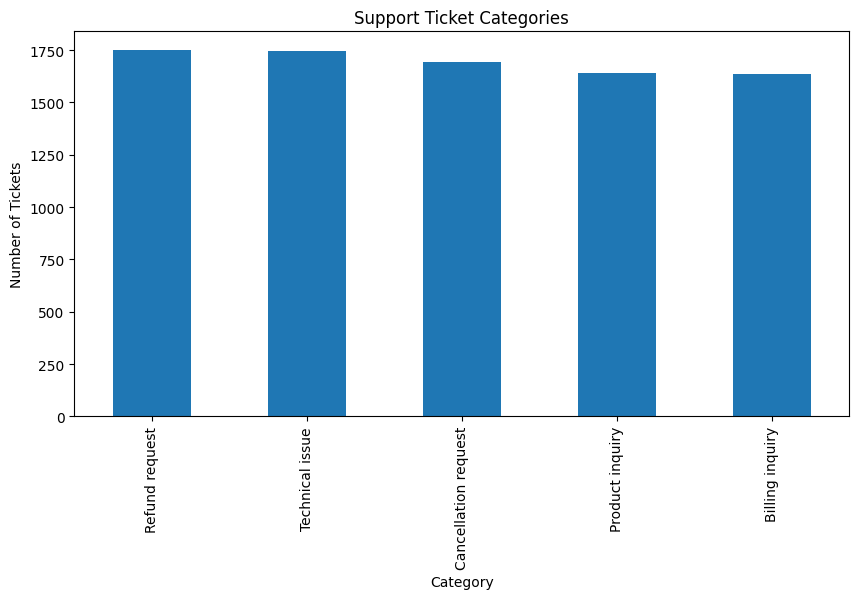

In [19]:
plt.figure(figsize=(10,5))

df['Ticket Type'].value_counts().plot(kind='bar')

plt.title("Support Ticket Categories")

plt.xlabel("Category")

plt.ylabel("Number of Tickets")

plt.show()

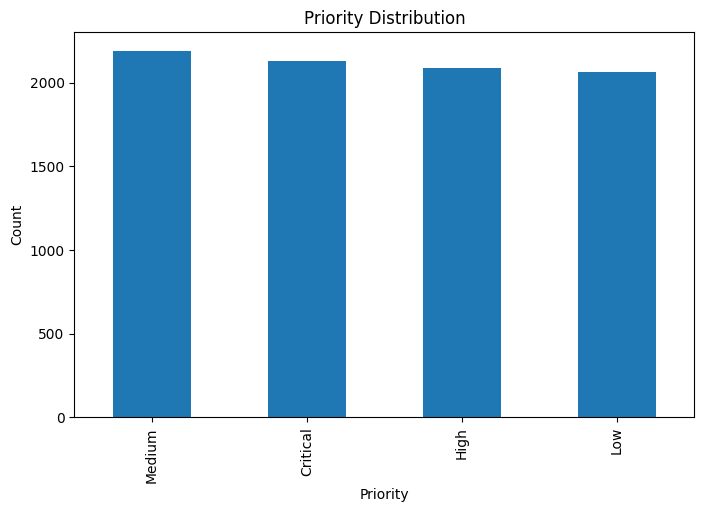

In [20]:
plt.figure(figsize=(8,5))

df['Ticket Priority'].value_counts().plot(kind='bar')

plt.title("Priority Distribution")

plt.xlabel("Priority")

plt.ylabel("Count")

plt.show()

Part 2: Text Cleaning & NLP Preprocessing

In [21]:
df['Ticket Description'].head()

,Ticket Description
0,I'm having an issue with the {product_purchase...
1,I'm having an issue with the {product_purchase...
2,I'm facing a problem with my {product_purchase...
3,I'm having an issue with the {product_purchase...
4,I'm having an issue with the {product_purchase...


In [22]:
df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [23]:
df.isnull().sum()

,0
Ticket Description,0
Ticket Type,0
Ticket Priority,0


In [24]:
df = df.dropna()

df.isnull().sum()

,0
Ticket Description,0
Ticket Type,0
Ticket Priority,0


In [25]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After :", df.shape)

Before: (8469, 3)
After : (8342, 3)


In [26]:
df['Ticket Description'] = df['Ticket Description'].str.lower()

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,i'm having an issue with the {product_purchase...,Technical issue,Critical
1,i'm having an issue with the {product_purchase...,Technical issue,Critical
2,i'm facing a problem with my {product_purchase...,Technical issue,Low
3,i'm having an issue with the {product_purchase...,Billing inquiry,Low
4,i'm having an issue with the {product_purchase...,Billing inquiry,Low


In [27]:
import string

df['Ticket Description'] = df['Ticket Description'].str.translate(
    str.maketrans('', '', string.punctuation)
)

In [28]:
import re

df['Ticket Description'] = df['Ticket Description'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

In [29]:
df['Ticket Description'] = df['Ticket Description'].str.strip()

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,im having an issue with the productpurchased p...,Technical issue,Critical
1,im having an issue with the productpurchased p...,Technical issue,Critical
2,im facing a problem with my productpurchased t...,Technical issue,Low
3,im having an issue with the productpurchased p...,Billing inquiry,Low
4,im having an issue with the productpurchased p...,Billing inquiry,Low


In [30]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [31]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [32]:
def remove_stopwords(text):
    words = text.split()

    filtered = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)

In [33]:
df['Clean_Text'] = df['Ticket Description'].apply(remove_stopwords)

df.head()

,Ticket Description,Ticket Type,Ticket Priority,Clean_Text
0,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist billin...
1,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist need c...
2,im facing a problem with my productpurchased t...,Technical issue,Low,im facing problem productpurchased productpurc...
3,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist proble...
4,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist note s...


In [34]:
comparison = pd.DataFrame({
    "Original": df['Ticket Description'].head(),
    "Cleaned": df['Clean_Text'].head()
})

comparison

,Original,Cleaned
0,im having an issue with the productpurchased p...,im issue productpurchased please assist billin...
1,im having an issue with the productpurchased p...,im issue productpurchased please assist need c...
2,im facing a problem with my productpurchased t...,im facing problem productpurchased productpurc...
3,im having an issue with the productpurchased p...,im issue productpurchased please assist proble...
4,im having an issue with the productpurchased p...,im issue productpurchased please assist note s...


In [35]:
df[df['Clean_Text'] == '']

,Ticket Description,Ticket Type,Ticket Priority,Clean_Text


In [36]:
df.head()

,Ticket Description,Ticket Type,Ticket Priority,Clean_Text
0,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist billin...
1,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist need c...
2,im facing a problem with my productpurchased t...,Technical issue,Low,im facing problem productpurchased productpurc...
3,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist proble...
4,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist note s...


Part 3: Feature Engineering (NLP)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import nltk
from nltk.stem import WordNetLemmatizer

In [38]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [39]:
lemmatizer = WordNetLemmatizer()

In [40]:
def lemmatize_text(text):

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [41]:
df["Processed_Text"] = df["Clean_Text"].apply(lemmatize_text)

df.head()

,Ticket Description,Ticket Type,Ticket Priority,Clean_Text,Processed_Text
0,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist billin...,im issue productpurchased please assist billin...
1,im having an issue with the productpurchased p...,Technical issue,Critical,im issue productpurchased please assist need c...,im issue productpurchased please assist need c...
2,im facing a problem with my productpurchased t...,Technical issue,Low,im facing problem productpurchased productpurc...,im facing problem productpurchased productpurc...
3,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist proble...,im issue productpurchased please assist proble...
4,im having an issue with the productpurchased p...,Billing inquiry,Low,im issue productpurchased please assist note s...,im issue productpurchased please assist note s...


In [42]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["Processed_Text"])

In [43]:
ticket_encoder = LabelEncoder()

y_category = ticket_encoder.fit_transform(
    df["Ticket Type"]
)

In [44]:
priority_encoder = LabelEncoder()

y_priority = priority_encoder.fit_transform(
    df["Ticket Priority"]
)

In [45]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

In [46]:
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

In [47]:
print("Training Shape :", X_train_cat.shape)

print("Testing Shape :", X_test_cat.shape)

Training Shape : (6673, 5000)
Testing Shape : (1669, 5000)


In [48]:
import joblib

joblib.dump(ticket_encoder, "ticket_type_encoder.pkl")

joblib.dump(priority_encoder, "priority_encoder.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [49]:
print(ticket_encoder.classes_)

print(priority_encoder.classes_)

['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']
['Critical' 'High' 'Low' 'Medium']


Part 4: Model Building

In [50]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

CATEGORY CLASSIFICATION


In [51]:
nb_category = MultinomialNB()

nb_category.fit(
    X_train_cat,
    y_train_cat
)

MultinomialNB()

In [52]:
nb_category_pred = nb_category.predict(
    X_test_cat
)

In [53]:
print("Naive Bayes - Category Classification")
print("-"*45)

print("Accuracy :",
      accuracy_score(y_test_cat, nb_category_pred))

print("Precision:",
      precision_score(
          y_test_cat,
          nb_category_pred,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test_cat,
          nb_category_pred,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_test_cat,
          nb_category_pred,
          average="weighted"
      ))

Naive Bayes - Category Classification
---------------------------------------------
Accuracy : 0.20071899340922708
Precision: 0.20187898311948657
Recall: 0.20071899340922708
F1 Score: 0.1952802356071737


In [54]:
lr_category = LogisticRegression(
    max_iter=1000
)

lr_category.fit(
    X_train_cat,
    y_train_cat
)

LogisticRegression(max_iter=1000)

In [55]:
lr_category_pred = lr_category.predict(
    X_test_cat
)

In [56]:
print("Logistic Regression - Category")
print("-"*45)

print("Accuracy :",
      accuracy_score(y_test_cat, lr_category_pred))

print("Precision:",
      precision_score(
          y_test_cat,
          lr_category_pred,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test_cat,
          lr_category_pred,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_test_cat,
          lr_category_pred,
          average="weighted"
      ))

Logistic Regression - Category
---------------------------------------------
Accuracy : 0.19472738166566805
Precision: 0.19478861657591484
Recall: 0.19472738166566805
F1 Score: 0.19429851170725657


In [57]:
category_results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(
            y_test_cat,
            nb_category_pred
        ),

        accuracy_score(
            y_test_cat,
            lr_category_pred
        )
    ]

})

category_results

,Model,Accuracy
0,Naive Bayes,0.200719
1,Logistic Regression,0.194727


PRIORITY CLASSIFICATION

In [58]:
nb_priority = MultinomialNB()

nb_priority.fit(
    X_train_pri,
    y_train_pri
)

MultinomialNB()

In [59]:
nb_priority_pred = nb_priority.predict(
    X_test_pri
)

In [60]:
print("Naive Bayes - Priority")
print("-"*40)

print("Accuracy :",
      accuracy_score(
          y_test_pri,
          nb_priority_pred
      ))

print("Precision:",
      precision_score(
          y_test_pri,
          nb_priority_pred,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test_pri,
          nb_priority_pred,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_test_pri,
          nb_priority_pred,
          average="weighted"
      ))

Naive Bayes - Priority
----------------------------------------
Accuracy : 0.2402636309167166
Precision: 0.23258355027795852
Recall: 0.2402636309167166
F1 Score: 0.23295310080324808


In [61]:
lr_priority = LogisticRegression(
    max_iter=1000
)

lr_priority.fit(
    X_train_pri,
    y_train_pri
)

LogisticRegression(max_iter=1000)

In [62]:
lr_priority_pred = lr_priority.predict(
    X_test_pri
)

In [63]:
print("Logistic Regression - Priority")
print("-"*45)

print("Accuracy :",
      accuracy_score(
          y_test_pri,
          lr_priority_pred
      ))

print("Precision:",
      precision_score(
          y_test_pri,
          lr_priority_pred,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test_pri,
          lr_priority_pred,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_test_pri,
          lr_priority_pred,
          average="weighted"
      ))

Logistic Regression - Priority
---------------------------------------------
Accuracy : 0.2606351108448173
Precision: 0.2599676717926016
Recall: 0.2606351108448173
F1 Score: 0.25994536577788796


In [64]:
priority_results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(
            y_test_pri,
            nb_priority_pred
        ),

        accuracy_score(
            y_test_pri,
            lr_priority_pred
        )
    ]

})

priority_results

,Model,Accuracy
0,Naive Bayes,0.240264
1,Logistic Regression,0.260635


In [65]:
joblib.dump(
    lr_category,
    "ticket_category_model.pkl"
)

joblib.dump(
    lr_priority,
    "ticket_priority_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


Part 5: Model Evaluation & Interactive Prediction

In [66]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [67]:
print("Category Classification Report")
print("="*50)

print(classification_report(
    y_test_cat,
    lr_category_pred,
    target_names=ticket_encoder.classes_
))

Category Classification Report
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.18      0.19       323
Cancellation request       0.19      0.18      0.19       334
     Product inquiry       0.20      0.19      0.19       326
      Refund request       0.19      0.19      0.19       344
     Technical issue       0.20      0.23      0.21       342

            accuracy                           0.19      1669
           macro avg       0.19      0.19      0.19      1669
        weighted avg       0.19      0.19      0.19      1669



<Figure size 1000x800 with 0 Axes>

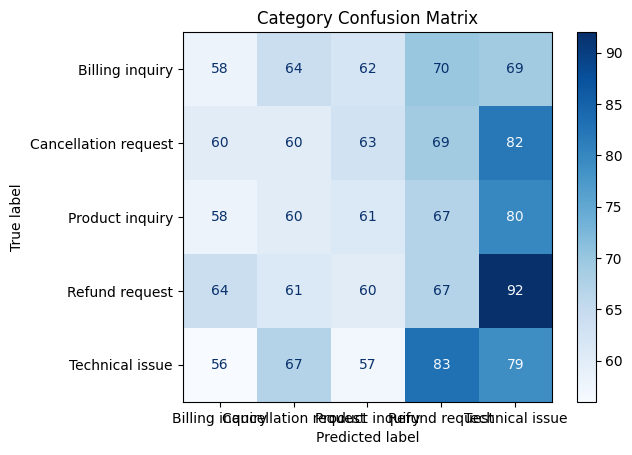

In [68]:
cm = confusion_matrix(
    y_test_cat,
    lr_category_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ticket_encoder.classes_
)

plt.figure(figsize=(10,8))

disp.plot(cmap="Blues")

plt.title("Category Confusion Matrix")

plt.show()

In [69]:
print("Priority Classification Report")
print("="*50)

print(classification_report(
    y_test_pri,
    lr_priority_pred,
    target_names=priority_encoder.classes_
))

Priority Classification Report
              precision    recall  f1-score   support

    Critical       0.26      0.23      0.24       421
        High       0.26      0.25      0.26       412
         Low       0.23      0.24      0.23       405
      Medium       0.29      0.32      0.30       431

    accuracy                           0.26      1669
   macro avg       0.26      0.26      0.26      1669
weighted avg       0.26      0.26      0.26      1669



<Figure size 600x600 with 0 Axes>

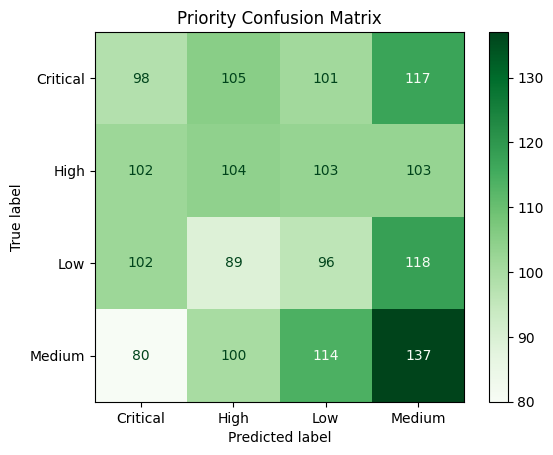

In [70]:
cm = confusion_matrix(
    y_test_pri,
    lr_priority_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=priority_encoder.classes_
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Greens")

plt.title("Priority Confusion Matrix")

plt.show()

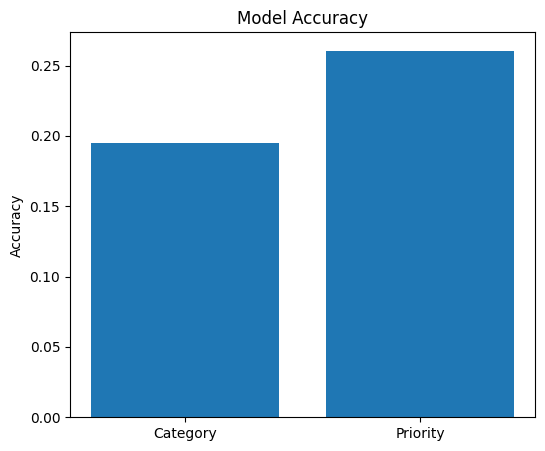

In [71]:
accuracy = [

    accuracy_score(
        y_test_cat,
        lr_category_pred
    ),

    accuracy_score(
        y_test_pri,
        lr_priority_pred
    )

]

models = [

    "Category",

    "Priority"

]

plt.figure(figsize=(6,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.show()

In [72]:
def predict_ticket(ticket):

    # Lowercase
    ticket = ticket.lower()

    # Remove punctuation
    ticket = re.sub(r"[^\w\s]", "", ticket)

    # Remove numbers
    ticket = re.sub(r"\d+", "", ticket)

    # Remove stopwords
    words = ticket.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    ticket = " ".join(words)

    # TF-IDF
    vector = tfidf.transform([ticket])

    # Predict Category
    category = lr_category.predict(vector)

    # Predict Priority
    priority = lr_priority.predict(vector)

    category = ticket_encoder.inverse_transform(category)

    priority = priority_encoder.inverse_transform(priority)

    print("="*50)

    print("Support Ticket")

    print("="*50)

    print(ticket)

    print()

    print("Predicted Category :", category[0])

    print("Predicted Priority :", priority[0])

In [73]:
predict_ticket(
    "My payment failed but money was deducted."
)

Support Ticket
payment failed money deducted

Predicted Category : Product inquiry
Predicted Priority : Low


In [74]:
predict_ticket(
    "I forgot my account password and cannot login."
)

Support Ticket
forgot account password cannot login

Predicted Category : Billing inquiry
Predicted Priority : High


In [75]:
predict_ticket(
    "Internet connection is not working properly."
)

Support Ticket
internet connection working properly

Predicted Category : Cancellation request
Predicted Priority : Medium


In [76]:
ticket = input("Enter Support Ticket : ")

predict_ticket(ticket)

Enter Support Ticket : My laptop is overheating after the latest update.
Support Ticket
laptop overheating latest update

Predicted Category : Product inquiry
Predicted Priority : High


In [77]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    ticket_encoder,
    "ticket_encoder.pkl"
)

joblib.dump(
    priority_encoder,
    "priority_encoder.pkl"
)

print("All files saved successfully!")

All files saved successfully!


# Business Insights

## Support Ticket Classification

This machine learning model automatically classifies incoming customer support tickets into predefined categories and predicts their priority level.

### Key Benefits

- Reduces manual ticket sorting.
- Improves response time.
- Automatically identifies urgent tickets.
- Helps support teams prioritize work efficiently.
- Enhances customer satisfaction.

### Technologies Used

- Python
- Pandas
- NLTK
- TF-IDF Vectorization
- Logistic Regression
- Scikit-learn

### Future Improvements

- Deploy as a web application using Streamlit or Flask.
- Integrate with real-time helpdesk software.
- Add multilingual support.
- Improve accuracy with transformer models like BERT.